# 모델 평가 및 개선  

지난 수업 시간을 통해 우리는 모델을 생성하고 차량 가격(price)을 예측했습니다. 이렇게 훈련 데이터(train data)의 목표변수값을 얼마나 잘 예측하였는지를 나타내는 것을 표본내 성능 검증(in-sample testing)이라고 하며, 제공된 표본에만 한정하여 <b>최적화</b>한 관계로, 일반화가 가능한지 확인이 필요합니다.   

이제 우리는 이 모델이 <b>실제 상황</b>에서 얼마나 정확한 예측을 할지를 결정해야 합니다. 즉 실제 상황에서의 모델 성능을 근사(approximate)하기 위하여, 테스트 데이터(test data)의 목표변수값을 얼마나 잘 예측하였는지를 나타내는 <b>표본외 성능 검증(out-of-sample testing)</b>에 대해 알아볼 필요가 있습니다. 즉, 한번도 보지 않은 새로운 데이터에 대한 성능 즉 <b>일반화 성능</b>을 개선하기 위한 다음과 같은 방법을 알아봅니다.  
    
* 데이터 크기 증가 : 교차검증  
* 모델 선택 함수 후보 용량 늘리기 혹은 줄이기 : 다차 다항함수 포함으로 모델 복잡도 증가 혹은 감소  
* 모델내 각 함수에 대한 선호도 조절(피처의 영향력 약화)로 과적합 방지 : 알파값을 이용한 리지회귀 즉, 패러미터를 0에 가깝게 어느 정도의 속도로 줄일까? 
* 교차검증과 함께 최상의 하이퍼패러미터(예, 알파값) 조합 탐색 : Grid Search

## 목차

* 0. 환경 준비
* 1. 모델 평가(표본외 성능)와 교차검증
* 2. 모델 선택: 과적합(Over-fitting), 과소적합(Under-fitting)과 모델 용량 결정
* 3. 모델내 함수 선호도 조절: 하이퍼패러미터와 리지회귀(Ridge regression
* 4. 하이퍼패러미터 최적화(Hyperparameter Optimization)와 Grid Search
* 5. 훈련데이터, 검증데이터, 테스트 데이터


<h2> 환경 준비 </h2>

다음 데이터 세트는 IBM의 Cloud object storage 서비스 상에 호스팅되어 있습니다. 무료 스토리지 공간을 활용하고자 하시면
<a href="https://cocl.us/DA101EN_object_storage"> 여기</a>를 클릭하십시오.

In [1]:
import pandas as pd
import numpy as np

# Import clean data 
# path = 'https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DA0101EN/module_5_auto.csv'
path = 'module_5_auto.csv'
df = pd.read_csv(path)
# df.to_csv('module_5_auto.csv')

먼저 수치형 데이터만 혹인해봅시다. 

In [2]:
df=df._get_numeric_data()
df.head()

,Unnamed: 0,Unnamed: 0.1,Unnamed: 0.1.1,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,...,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
0,0,0,0,3,122,88.6,0.811148,0.890278,48.8,2548,...,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,0,1
1,1,1,1,3,122,88.6,0.811148,0.890278,48.8,2548,...,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,0,1
2,2,2,2,1,122,94.5,0.822681,0.909722,52.4,2823,...,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,0,1
3,3,3,3,2,164,99.8,0.848630,0.919444,54.3,2337,...,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,0,1
4,4,4,4,2,164,99.4,0.848630,0.922222,54.3,2824,...,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,0,1


플롯팅을 위한 라이브러리

In [3]:
from ipywidgets import interact, interactive, fixed, interact_manual

<h2 id="ref0">0. Plotting 함수 정의</h2>

*참고사항* seaborn distplot() 기능 deprecated 계획에 따라, [Seaborn Version 0.11.0 is here with displot, histplot and ecdfplot](https://cmdlinetips.com/2020/09/seaborn-version-0-11-0-is-here-with-displot-histplot-and-ecdfplot/)내용을 기반으로 distplot()은 kdeplot()으로 코드 수정함(2021.03.07)

In [4]:
def DistributionPlot(RedFunction, BlueFunction, RedName, BlueName, Title):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))

#   ax1 = sns.distplot(RedFunction, hist=False, color="r", label=RedName)   
    ax1 = sns.kdeplot(RedFunction, color="r")
#   ax2 = sns.distplot(BlueFunction, hist=False, color="b", label=BlueName, ax=ax1)
    ax2 = sns.kdeplot(BlueFunction, color="b", ax=ax1)

    plt.title(Title)
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')
#   plt.legend(labelcolor = ["r", "b"], labels=[RedName, BlueName])
    plt.legend(labels=[RedName, BlueName])
    plt.show()
    plt.close()

In [5]:
def PollyPlot(xtrain, xtest, y_train, y_test, lr,poly_transform):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))
    
    
    #training data 
    #testing data 
    # lr:  linear regression object 
    #poly_transform:  polynomial transformation object 
 
    xmax=max([xtrain.values.max(), xtest.values.max()])

    xmin=min([xtrain.values.min(), xtest.values.min()])

    x=np.arange(xmin, xmax, 0.1)


    plt.plot(xtrain, y_train, 'ro', label='Training Data')
    plt.plot(xtest, y_test, 'go', label='Test Data')
    plt.plot(x, lr.predict(poly_transform.fit_transform(x.reshape(-1, 1))), label='Predicted Function')
    plt.ylim([-10000, 60000])
    plt.ylabel('Price')
    plt.legend()

<h2 id="ref1">1. 모델 평가(표본외 성능)와 교차검증</h2>
<h3>1.1 테스트데이터 분리에 의한 성능 평가(일반화 성능 근사)</h3>

<p>데이터를 훈련(training) 및 테스트(test) 데이터로 분할하는 단계는 추후 모델 테스트를 위해 중요합니다. 목표 데이터인 <b>price</b>는 별도 데이터프레임 <b>y</b>에 배치합니다.

In [6]:
y_data = df['price']

x_data 변수에는 price 데이터를 제외한 모든 데이터를 할당

In [7]:
x_data=df.drop('price',axis=1)

`train_test_split`함수를 사용하여 데이터를 훈련(training) 및 테스트(test) 데이터로 무작위 분할합니다.

In [8]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.15, random_state=1)


print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])


number of test samples : 31
number of training samples: 170


<b>test_size</b> 매개변수는 테스트(test) 셋으로 분할되는 데이터의 비율을 설정합니다. 위 코드에서 테스트 셋은 전체 데이터셋의 10%로 설정되어 있습니다.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제  #1):</h4>

`train_test_split`기능을 사용하여 샘플 데이터의 40%가 테스트에 활용되도록 데이터셋을 분할하고 `random_state` 매개 변수를 0으로 설정합니다. 함수의 출력은 `x_train_1`, `x_test_1`, `y_train_1`및 `y_test_1`이어야합니다.
</div>

In [9]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

x_train1, x_test1, y_train1, y_test1 = train_test_split(x_data, y_data, test_size=0.4, random_state=0) 
print("number of test samples :", x_test1.shape[0])
print("number of training samples:",x_train1.shape[0])

-->

<b>linear_model<b> 모듈에서 <b>LinearRegression</b>을 가져(import) 오겠습니다.

In [10]:
from sklearn.linear_model import LinearRegression

선형회귀 객체를 생성합니다. 

In [11]:
lre=LinearRegression()

horsepower 피처를 사용하여 모델을 fit합니다. 

In [12]:
lre.fit(x_train[['horsepower']], y_train)

LinearRegression()

테스트데이터에서 $R^2$를 계산해봅시다.

In [13]:
lre.score(x_test[['horsepower']], y_test)

0.707688374146705

훈련데이터 사용시 $R^2$가 훨씬 더 작다는 것을 알 수 있습니다.

In [14]:
lre.score(x_train[['horsepower']], y_train)

0.6449517437659684

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제  #2): </h4>
<b> 
데이터의 90%를 훈련(training) 데이터로 사용하고, 테스트 데이터에서 $R^2$를 구합니다. 
</b>
</div>

In [15]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

x_train1, x_test1, y_train1, y_test1 = train_test_split(x_data, y_data, test_size=0.1, random_state=0)
lre.fit(x_train1[['horsepower']],y_train1)
lre.score(x_test1[['horsepower']],y_test1)

-->

종종 충분한 테스트 데이터가 없는 경우에는 교차검증(cross-validation)을 수행하여 테스트 데이터의 부족을 해결할 수 있습니다. 다음 섹션부터 교차검증에 사용할 수있는 몇 가지 방법을 살펴 보겠습니다.

<h3>1.2 교차검증(Cross-validation) Score</h3>

데이터 양이 충분하지 않을 경우, 데이터셋을 폴드(Fold)라고 하는 단위로 k개를 무작위로 나눕니다. 이것은 데이터 양이 충분하지 않은 경우, 성능 측정의 신뢰도를 높이는 방법으로 교차검증(Cross-validation)이라 합니다. 다음 그림은 k=5로 나눈 경우이며, 각 반복시의 성능(MSE 혹은 결정계수)을 평균한 것을 최종 모델의 성능으로 합니다. 

![cross validation](http://ethen8181.github.io/machine-learning/model_selection/img/kfolds.png)

교차검증은, Grid Search(만족할 만한 하이퍼패러미터의 조합을 찾을때까지 교차검증과 함께 수동으로 조정하는 방법)와 함께, 최적의 모델 매개변수(parameter)를 찾는 방법입니다.

<b>cross_val_score</b> 모듈에서 <b>model_selection</b>을 가져옵니다(import).

In [16]:
from sklearn.model_selection import cross_val_score

피처`horsepower`와 목표 데이터 즉`y_data`를 객체에 입력합니다. 매개변수`cv`는 폴딩 횟수를 결정합니다. 여기서는 `cv`를 4로 설정합니다. 

In [17]:
Rcross = cross_val_score(lre, x_data[['horsepower']], y_data, cv=4)

기본 성능평가 점수(score)는 $R^2$로 제공됩니다. 이 때 제공되는 배열의 각 요소는 각 폴드 수행시의 $R^2$값을 가지고 있습니다. 

In [18]:
Rcross

array([0.7746232 , 0.51716687, 0.74785353, 0.04839605])

배열내 추정치들의 평균 및 표준편차를 계산합니다. 

In [19]:
print("폴드의 평균: ", Rcross.mean(), "표준편차: " , Rcross.std())

폴드의 평균:  0.522009915042119 표준편차:  0.2911839444756029


cross_val_score는 클수록 좋은 성능을 나타냅니다. 그러므로 기본으로 제공되는 $R^2$값이 아닌, 다음과 같이 `scoring` 메트릭을 `neg_mean_squared_error`로 설정한 경우, MSE(mean squared error)의 반대값(음수값)을 점수(score)로 사용하도록 음수를 붙여서 계산합니다.

In [20]:
-1* cross_val_score(lre,x_data[['horsepower']], y_data,cv=4,scoring='neg_mean_squared_error')

array([20254142.84026704, 43745493.2650517 , 12539630.34014931,
       17561927.72247591])

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제  #3): </h4>
<b> 
2개 폴드를 갖는 교차검증(cross validation)으로 평균 $R^2$를 계산합니다. 이 때 `horsepower`를 feature로서 사용합니다.
</b>
</div>

In [21]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

Rc=cross_val_score(lre,x_data[['horsepower']], y_data,cv=2)
Rc.mean()

-->

`cross_val_predict`함수를 사용하여 출력을 예측할 수도 있습니다. 이 함수는 입력의 각 요소가 테스트셋에 있을때 해당 요소가 얻은 예측을 반환합니다. 

In [22]:
from sklearn.model_selection import cross_val_predict

<b>'horsepower'</b> 피처와 목표 데이터 <b>y_data</b>를 객체에 입력합니다. 매개변수 'cv'는 폴드수를 결정하며 4로 설정하면 다음과 같은 결과를 얻을 수 있습니다. 

In [23]:
yhat = cross_val_predict(lre,x_data[['horsepower']], y_data,cv=4)
yhat[0:5]

array([14141.63807508, 14141.63807508, 20814.29423473, 12745.03562306,
       14762.35027598])

<h2 id="ref2">2. 모델 선택 : 과적합(Overfitting) 혹은 과소적합(Underfitting)과 모델 용량 결정</h2>

훈련데이터에 충분히 최적화되지 않은 경우 과소적합(Under-fitting)이 발생할 수 있습니다. 

그러나, 다항회귀(Polynomial Regression)를 적용하여 훈련데이터에 대한 모델 최적화에 집중하는 경우 과적합(Over-fitting)이 발생하기 쉽습니다. 이것은 고차(higher-order) 다항회귀의 경우 단순선형회귀에 비해 훨씬 유연한 관계로 노이즈에 민감한 모델이 만들어지기 때문입니다. 

이러한 과적합(Over-fitting)발생 여부는 결정계수($R^2$) 혹은 MSE가 훈련데이터 대비 테스트데이터에 대해 성능이 좋지 않은 경우 의심해볼 수 있습니다. 

<h3>2.1 분포도(Distribution Plot)기반 모델 평가 


테스트 데이터(OOS 즉 out of sample data라고도 함)는 모델이 실제 세계에서 얼마나 잘 수행되는지를 훨씬 더 잘 측정하는 것으로 밝혀졌습니다. 이유는 과적합 때문으로 몇 가지 예를 살펴보도록 하겠습니다. 이러한 차이는 다중선형회귀 및 다항회귀에서 더 분명해 지므로 해당 측면에서 과적합(overfitting)을 살펴보겠습니다.

다중선형회귀객체를 만들고 <b>'horsepower'</b>, <b>'curb-weight'</b>, <b>'engine-size'</b>, <b>'highway-mpg'</b> 피처를 사용하여 모델을 훈련시켜 봅시다. 

In [24]:
lr = LinearRegression()
lr.fit(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_train)

LinearRegression()

훈련 데이터를 사용하여 예측 :

In [25]:
yhat_train = lr.predict(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
yhat_train[0:5]

array([11927.70699817, 11236.71672034,  6436.91775515, 21890.22064982,
       16667.18254832])

테스트 데이터를 사용하여 예측:

In [26]:
yhat_test = lr.predict(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
yhat_test[0:5]

array([11349.16502418,  5914.48335385, 11243.76325987,  6662.03197043,
       15555.76936275])

훈련 및 테스트 데이터를 각각 사용하여 모델 평가를 수행해 보겠습니다. 먼저 플로팅을 위해 seaborn 및 matplotlibb 라이브러리를 가져옵니다.

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib widget
import seaborn as sns

In [28]:
plt.style.use('seaborn')

훈련 데이터의 예측값 분포를 살펴 보겠습니다.

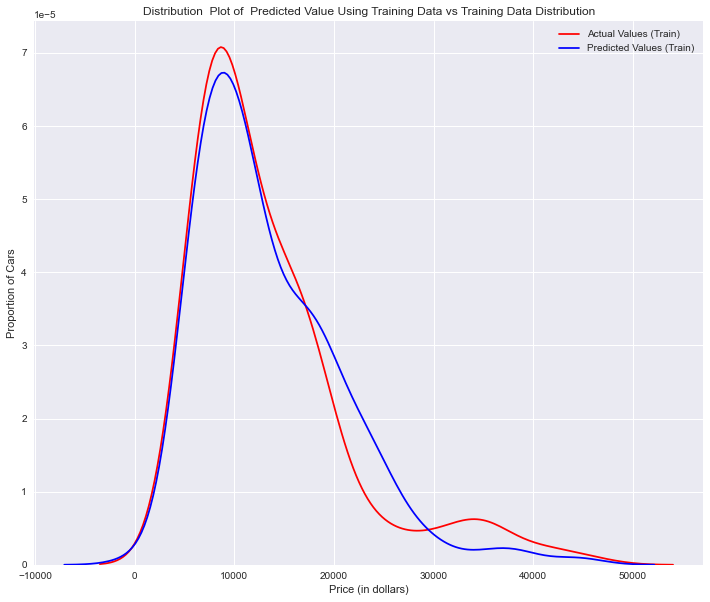

In [29]:
Title = 'Distribution  Plot of  Predicted Value Using Training Data vs Training Data Distribution'
DistributionPlot(y_train, yhat_train, "Actual Values (Train)", "Predicted Values (Train)", Title)

그림 1: 훈련데이터 값과, 훈련데이터 기반 예측 값 플롯

이제까지 훈련데이터 셋을 기반으로 학습한 결과로 생성된 모델은 잘 작동하는 것 같습니다.  

그러나 이렇게 생성된 모델이 테스트 데이터셋을 통해 새로운 데이터를 만나면 어떻게 될까요? 모델이 테스트데이터로 부터 새 값을 입력받아 예측시 예측값의 분포가 실제 목표값과 크게 달라질 수 있다는 것을 다음 부문에서 확인할 수 있습니다. 

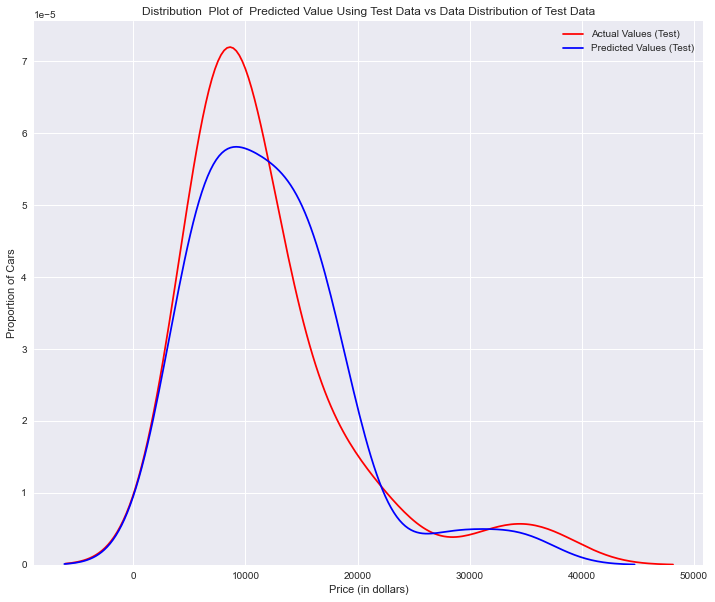

In [30]:
Title='Distribution  Plot of  Predicted Value Using Test Data vs Data Distribution of Test Data'
DistributionPlot(y_test,yhat_test,"Actual Values (Test)","Predicted Values (Test)",Title)

그림 2: 실제 테스트 데이터 값과, 테스트 데이터 기반 예측값을 플롯합니다.

그림1과 그림2 비교; 그림1의 데이터 분포 그림이 데이터를 훨씬 더 잘 추적하고 있다는 것은 분명합니다. 이러한 차이는 그림 2의 5000에서 15,000 구간 확인시 더 분명해집니다(분포 모양이 예외적으로 다른 곳입니다).   

이제 테스트 데이터셋으로 분석시 현재 다항회귀의 예측 정확도가 떨어지는 지 확인해봅시다.

In [31]:
from sklearn.preprocessing import PolynomialFeatures

<h3>2.1 과적합(Overfitting)</h3>
과적합은 모델이 기본적으로 추적해야 점들이 아닌 노이즈에 적합시 발생합니다. 따라서 테스트 셋를 사용하여 모델을 테스트시 모델은 처음 의도한 관계선이 아닌 노이즈에 대해 모델링된 관계로, 모델은 좋은 성능을 내지 않게 됩니다. 이러한 부문에 대해 5차 다항식 모델로서 설명해보겠습니다. 

데이터의 55%를 테스트에 사용하고 나머지는 훈련(training)에 사용하겠습니다.

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.45, random_state=0)

<b>'horse power'</b>피처에 대해 5차 다항식 변환을 수행합니다.

In [33]:
pr = PolynomialFeatures(degree=5)
x_train_pr = pr.fit_transform(x_train[['horsepower']])
x_test_pr = pr.fit_transform(x_test[['horsepower']])
pr

PolynomialFeatures(degree=5)

이제 선형회귀모델 `poly`를 만들고 훈련해 보겠습니다.

In [34]:
poly = LinearRegression()
poly.fit(x_train_pr, y_train)

LinearRegression()

`predict`메소드를 사용하여 모델의 예측값을 `yhat`에 할당합니다.

In [35]:
yhat = poly.predict(x_test_pr)
yhat[0:5]

array([ 6728.70501896,  7308.02845162, 12213.7843307 , 18893.19108677,
       19995.88963424])

처음 5개의 예측 값을 실제 목표값과 비교해 보겠습니다.

In [36]:
print("Predicted values:", yhat[0:4])
print("True values:", y_test[0:4].values)

Predicted values: [ 6728.70501896  7308.02845162 12213.7843307  18893.19108677]
True values: [ 6295. 10698. 13860. 13499.]


실습 시작 부분에서 정의한 `PollyPlot`함수를 사용하여 훈련 데이터, 테스트 데이터 및 예측함수를 표시합니다.

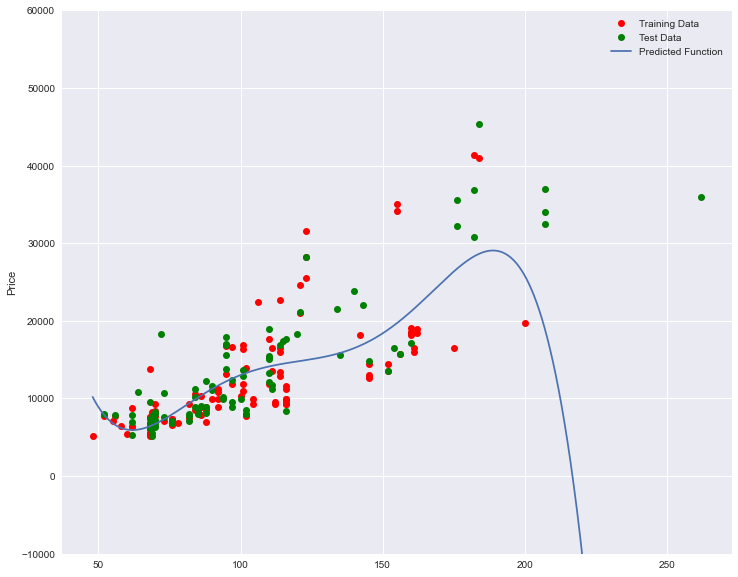

In [37]:
PollyPlot(x_train[['horsepower']], x_test[['horsepower']], y_train, y_test, poly,pr)

그림(Figure) 4 다항회귀모델, 빨간색 점은 학습 데이터, 녹색 점은 테스트 데이터, 파란색 선은 모델 예측을 나타냅니다.

추정함수가 데이터를 잘 추적하는 것처럼 보이지만 horsepower가 약 200인 곳에서 함수가 데이터 포인트에서 벗어나기 시작합니다.

<h4> 훈련데이터의 결정계수($R^2$)</h4>

In [38]:
poly.score(x_train_pr, y_train)

0.5567716902635091

<h4> 테스트데이터의 결정계수($R^2$)</h4>

In [39]:
poly.score(x_test_pr, y_test)

-29.871418859187518

훈련 데이터의 $R^2$는 0.5567이고 테스트 데이터의 $R^2$는 -29.87입니다. $R^2$가 낮을수록 안 좋은 모델이며 음수인 $R^2$는  과적합의 신호입니다.

<h4> 모델 선택을 위한 다양한 다항식 차수(order) 실험</h4>

테스트 데이터를 기반으로 다른 차수 다항식에 대해 $R^2$가 어떻게 변경되는지 확인하고 결과를 플로팅해보겠습니다. 

Text(3, 0.75, 'Maximum R^2 ')

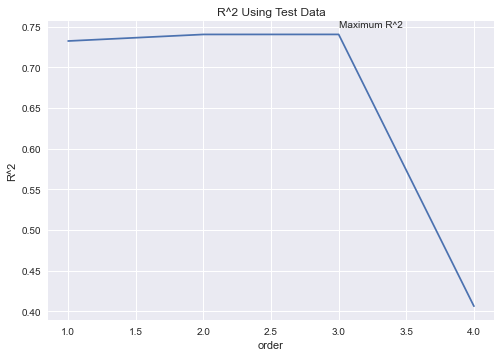

In [40]:
Rsqu_test = []

order = [1, 2, 3, 4]
for n in order:
    pr = PolynomialFeatures(degree=n)
    
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    
    x_test_pr = pr.fit_transform(x_test[['horsepower']])    
    
    lr.fit(x_train_pr, y_train)
    
    Rsqu_test.append(lr.score(x_test_pr, y_test))

plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
plt.text(3, 0.75, 'Maximum R^2 ')    

3차 다항식이 사용될 때까지 $R^2$값이 점차 증가하는 것을 볼 수 있습니다. 그러다가 $R^2$값이 4차 다항식에서 엄청나게 작아집니다. 

`r` 함수를 다음과 같이 정의하여 사용하고자 합니다. 다음 셀을 실행하십시오.

In [41]:
def f(order, test_data):
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=test_data, random_state=0)
    pr = PolynomialFeatures(degree=order)
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    x_test_pr = pr.fit_transform(x_test[['horsepower']])
    poly = LinearRegression()
    poly.fit(x_train_pr,y_train)
    PollyPlot(x_train[['horsepower']], x_test[['horsepower']], y_train,y_test, poly, pr)

다음 인터페이스를 사용하면 다양한 다항식 차수(order)와 데이터 양(test_data 분할 비율 조절)을 실험해볼 수 있습니다. 화면상에 나타난 동그라미를 움직여서 결과를 확인해보시기 바랍니다.

In [42]:
interact(f, order=(0, 6, 1), test_data=(0.05, 0.95, 0.05))

interactive(children=(IntSlider(value=3, description='order', max=6), FloatSlider(value=0.45, description='tes…

<function __main__.f(order, test_data)>

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제  #4a):</h4>

<b>하나 이상의 피처와 함께 다항식 변환을 수행할 수 있습니다. 2차 `PolynomialFeatures`객체 `pr1`을 생성하십시오.</b>
</div>

해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

pr1=PolynomialFeatures(degree=2)

-->

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제  #4b): </h4>

<b> 
'horsepower', 'curb-weight', 'engine-size', 'highway-mpg'피처에 대해 훈련 및 테스트 샘플을 변환합니다. 힌트 : 'fit_transform' 메소드를 사용
</b>
</div>

해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

x_train_pr1=pr.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])

x_test_pr1=pr.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])

-->

<!-- The answer is below:

x_train_pr1=pr.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
x_test_pr1=pr.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])

-->

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제  #4c): </h4>
<b> 
신규 피처에는 몇개의 차원(dimension)이 있습니까? 힌트 :  "shape"  속성을 사용
</b>
</div>

해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

There are now 15 features: x_train_pr1.shape 

-->

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제  #4d): </h4>

<b> 
선형회귀모델 "poly1"을 생성합니다. 이 때 polynomial feature를 사용한 "fit"방법으로 객체를 훈련하십시오</b>
</div>

해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

poly1=linear_model.LinearRegression().fit(x_train_pr1,y_train)

-->

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제  #4e): </h4>
<b> 'predict' 메소드를 사용하여 polynomial feature상의 출력을 예측한 다음 'DistributionPlot'함수를 사용하여 예측된 출력과 테스트데이터의 분포를 표시하십시오.</ b>
</div>

해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

yhat_test1=poly1.predict(x_test_pr1)
Title='Distribution  Plot of  Predicted Value Using Test Data vs Data Distribution of Test Data'
DistributionPlot(y_test, yhat_test1, "Actual Values (Test)", "Predicted Values (Test)", Title)

-->

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제  #4f): </h4>

<b>분포도(distribution plot)를 사용하여 예측된 price가 실제 price보다 정확하지 않은 2개 지역을 확인하십시오. </b>
</div>

해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

The predicted value is lower than actual value for cars where the price  $ 10,000 range, conversely the predicted price is larger than the price cost in the $30, 000 to $40,000 range. As such the model is not as accurate in these ranges .
    
-->

<img src = "https://ibm.box.com/shared/static/c35ipv9zeanu7ynsnppb8gjo2re5ugeg.png" width = 700, align = "center">


<h2 id="ref3">3. 모델내 함수 선호도 조절: 하이퍼패러미터와 리지회귀(Ridge regression)</h2> 

데이터셋에는 많은 피처(features)를 사용하여 모델을 적합시 자연스럽게, 훈련데이터에 지나치게 집중함으로써 실제 테스트 데이터에서는 결과가 나쁘게 나오는, 과적합(overfitting)이 발생할 수 있습니다. 이러한 과적합은 훈련데이터에 대한 MSE, 결정계수($R^2$)가 테스트데이터보다 좋을 때 의심할 수 있습니다. 

이러한 과적합을 해결하는 방법으로 다음 3가지가 존재합니다. 
1. 훈련데이터 양이 적은 경우, 적은 훈련 데이터로 인하여 일반화 성능이 떨어지므로 [훈련 데이터를 지능적으로 생성](https://blog.naver.com/laonple/220534098902)하거나 늘림
2. **훈련시 사용하는 피처(features)를 줄이는 방법**: 모델 용량 즉 함수의 복잡성을 줄인다. 즉, 핵심정보가 아닌 일부 정보를 포기(차원의 저주를 피하기 위해)하는 것으로 특별한 알고리즘(딥러닝의 경우, Drop-out)에 의해 자동으로 수행가능하나 결과에 중요한 영향을 미치는 피처가 버려지는 일이 발생할 단점 존재  
3. **규제(Regularization)을 사용하는 방법** : 모든 피처(features)를 사용하나 대신 매개변수의 값을 줄여서 해당 항의 영향을 최소화하거나 매개변수값을 0으로 하여 다항식의 함수가 간단해지도록 하는 효과. 즉, 훈련데이터에 집중하는 것을 피하도록 일종의 페널티를 부과하는 방법.   

이중 두번째 규제(Regularization) 방법과 관련되어 다음과 같은 2가지 방법이 존재합니다.
1. **L1 Regularization** : 피처 선택 - 패러미터의 값을 0으로 하여 변수 제거 혹은 영향을 크게 미치는 핵심 피처들만 반영 효과
2. **L2 규제(Regularization)인 리지 회귀** : 전반적으로 패러미터의 값이 작아지게(weight decay) 함   

이 섹션에서는 Ridge Regression을 검토하여 알파(Alfa) 매개 변수가 모델을 어떻게 변경하는지 살펴 봅니다. 참고로 이번 실습에서 test data로 표시된 부분은 실제로는 validation data로서 사용된 것입니다.  

데이터에 대해 2차 다항식 변환을 수행해 봅시다.

In [43]:
pr=PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])
x_test_pr=pr.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])

<b>선형모델</b> 모듈에서 <b>Ridge</b>를 가져옵니다. 

In [44]:
from sklearn.linear_model import Ridge

<b>정규화 매개변수(alpha)</b>를 0.1로 설정하여 Ridge회귀 객체를 만들어 보겠습니다.

In [45]:
RigeModel=Ridge(alpha=0.1)

일반적 회귀와 마찬가지로 <b>fit</b> 방법을 사용하여 모델을 피팅할 수 있습니다.

In [46]:
RigeModel.fit(x_train_pr, y_train)

C:\Users\user\anaconda3\envs\ds2\lib\site-packages\sklearn\linear_model\_ridge.py:147: LinAlgWarning: Ill-conditioned matrix (rcond=1.02972e-16): result may not be accurate.
  return linalg.solve(A, Xy, sym_pos=True,


Ridge(alpha=0.1)

마찬가지로 예측값을 얻을 수 있습니다.

In [47]:
yhat = RigeModel.predict(x_test_pr)

처음 5개 샘플의 예측값과 테스트셋내 값을 비교해 보겠습니다.

In [48]:
print('predicted:', yhat[0:4])
print('test set :', y_test[0:4].values)

predicted: [ 6567.83081933  9597.97151399 20836.22326843 19347.69543463]
test set : [ 6295. 10698. 13860. 13499.]


테스트 오류를 최소화하는 Alfa 값을 선택합니다. 예를 들어 다음과 같이 for 루프를 사용하여 Alfa값을 선택할 수 있습니다. 

In [49]:
Rsqu_test = []
Rsqu_train = []
# dummy1 = []
ALFA = 10 * np.array(range(0,1000))
for alfa in ALFA:
    RigeModel = Ridge(alpha=alfa) 
    RigeModel.fit(x_train_pr, y_train)
    Rsqu_test.append(RigeModel.score(x_test_pr, y_test))
    Rsqu_train.append(RigeModel.score(x_train_pr, y_train))

다른 Alpha 값에 대해  $R^2$의 값을 그릴 수 있습니다.

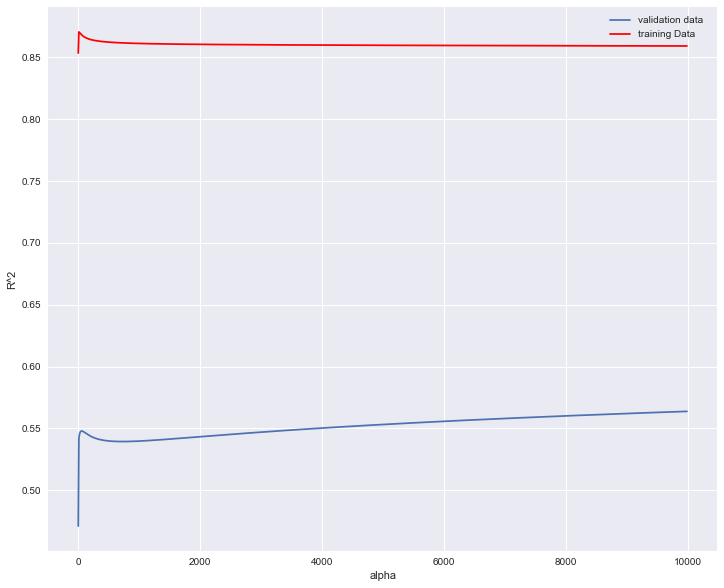

In [50]:
width = 12
height = 10
plt.figure(figsize=(width, height))

plt.plot(ALFA,Rsqu_test, label='validation data  ')
plt.plot(ALFA,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()

그림(Figure) 6 : 파란색 선은 테스트데이터의 $R^2$, 빨간색 선은 훈련데이터의 $R^2$. x축은 Alfa의 다양한 값을 나타내고 있다. 

그림(figure) 6의 빨간색 선은 훈련데이터의 $R^2$로, Alpha가 증가하면 $R^2$가 감소합니다. 따라서 Alfa가 증가함에 따라 모델은 훈련데이터에서 성능이 저하됩니다. 파란색 선은 검증(validation) 데이터의 $R^2$를 나타내며, Alfa 값 증가시 $R^2$가 감소합니다.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제 #5): </h4>

다항 특성에 기반한 Ridge 회귀 및 $R^2$를 계산합니다. 이 때, 훈련데이터(training data)를 이용하여 모델을 훈련하고 테스트데이터(test data)를 이용하여 모델을 테스트합니다. alpha 매개변수는 10으로 설정해야합니다. 
</div>

In [51]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

RigeModel = Ridge(alpha=10)           ;0을 10으로 수정함  
RigeModel.fit(x_train_pr, y_train)
RigeModel.score(x_test_pr, y_test)

-->

<h2 id="ref4">4. 하이퍼패러미터 최적화(Hyperparameter Optimization)와 Grid Search</h2>

GridSearch는 최상의 모델 성능을 제공하기 위하여 만족할 만한 **하이퍼패러미터의 조합**을 찾을때까지 교차검증과 함께 **조정**하는 방법입니다. 

*참고: 패러미터와 하이퍼패러미터의 차이
> 패러미터 : 훈련과정에서 자동 생성   
> 하이퍼패러미터 : 훈련전 수동으로 지정 

Alfa는 이러한 하이퍼파라미터의 예입니다. sklearn에는 최상의 하이퍼파라미터를 찾는 프로세스를 더 간단하게 만드는 <b>GridSearchCV</b> 클래스가 있습니다.

<b>model_selection</b> 모듈에서 <b>GridSearchCV</b>를 가져옵니다.

In [52]:
from sklearn.model_selection import GridSearchCV

매개변수 값 Dictionary를 만듭니다.

In [53]:
parameters1= [{'alpha': [0.001,0.1,1, 10, 100, 1000, 10000, 100000, 1000000]}]
parameters1

[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000]}]

리지 객체를 생성합니다.

In [54]:
RR=Ridge()
RR

Ridge()

리지 그리드 검색 객체 만들기

In [55]:
Grid1 = GridSearchCV(RR, parameters1,cv=4)

모델 핏팅하기

In [56]:
Grid1.fit(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_train)

GridSearchCV(cv=4, estimator=Ridge(),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000,
                                    1000000]}])

위의 코드 실행으로 객체는 검증 데이터를 기반으로 최상의 매개변수 값을 찾습니다. 이제 다음과 같이 최적의 매개변수를 가진 `best_estimatoer_`를 변수 BestRR에 할당합니다. 

In [57]:
BestRR=Grid1.best_estimator_
BestRR

Ridge(alpha=10000)

In [58]:
# added by Hyojung
scores = Grid1.cv_results_
scores['mean_test_score']   # 실제로는 mean_validation_score임

array([0.58245722, 0.58245877, 0.58247281, 0.5826117 , 0.58386051,
       0.589967  , 0.59619019, 0.5699674 , 0.55850584])

이제 테스트 데이터에서 모델을 테스트합니다.

In [59]:
#Grid1.best_estimator_.score(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_test)  
BestRR.score(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_test)

0.7722630851874495

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h4> 문제 #6): </h4>
alpha 매개변수 및 정규화 매개변수에 대한 그리드 검색을 수행하여 최상의 매겨변수를 찾으시오. 
</div>

In [60]:
# 아래에 코드를 작성하고 Shift + Enter를 눌러 실행하십시오.


해답을 보려면 <b>여기</b>를 더블클릭하십시오

<!-- 해답:

parameters2= [{'alpha': [0.001,0.1,1, 10, 100, 1000,10000,100000,100000],'normalize':[True,False]} ]
Grid2 = GridSearchCV(Ridge(), parameters2,cv=4)
Grid2.fit(x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']],y_data)
Grid2.best_estimator_

-->

<h2 id="ref5">5. 훈련데이터, 검증데이터, 테스트데이터</h2>

종종 검증데이터(validation data)와 테스트데이터(test data)는 혼용되어 사용되는 경향이 있습니다. 이것은 교차검증(cross validation)으로 인하여 폴드 수 지정 후 훈련데이터(training data)를 제공하면 검증데이터(validation data)가 머신러닝 라이브러리내에서 내부적으로 처리되는 경우가 많기 때문입니다. 

훈련데이터, 검증데이터, 테스트데이터의 다음과 같이 활용됩니다. 
* 훈련(training) 데이터셋 : 모델을 훈련데이터셋에 적합(fit)시 사용되는 데이터셋
* 검증(validation) 데이터셋 : 모델 하이퍼패러미터(alpha값, 학습율 등) 튜닝을 위해 사용되는 데이터셋
* 테스트(test) 데이터셋 : 최종 모델의 평가지표 산출시 사용되는 사용되는 데이터셋

모델의 최종 성능은 한번도 사용하지 않은 테스트셋(test set)으로 수행합니다. 

다음은 교차검증을 함께 수행시의 데이터셋 활용의 전체 구조입니다.

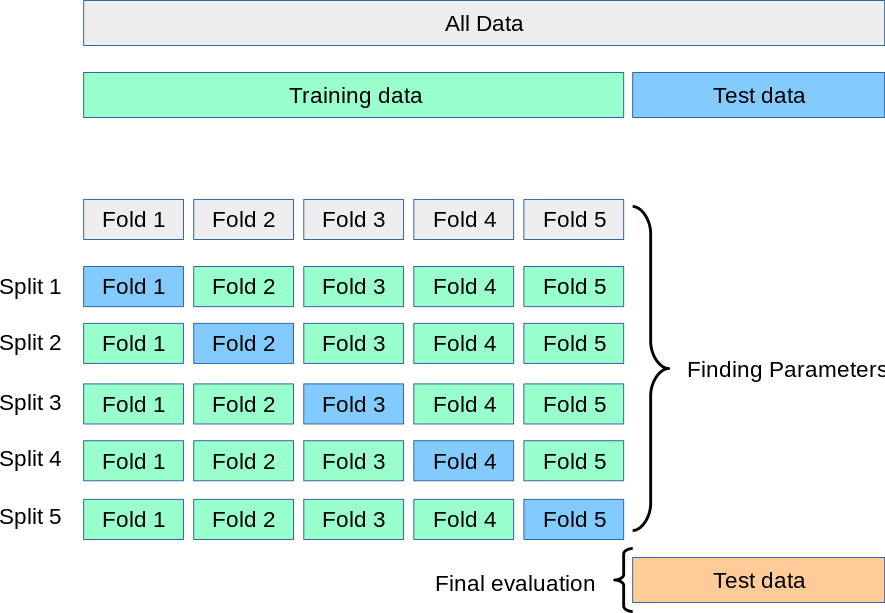

<center>출처:<a href="https://scikit-learn.org/stable/modules/cross_validation.html">Cross-validation: evaluating estimator performance</a></center>

교차검증과 함께 하이퍼패러니터 튜닝등 모델의 성능 평가시의 데이터 사용 부문을 요약하면 다음과 같습니다.   
<img src="https://scikit-learn.org/stable/_images/grid_search_workflow.png" alt="모델 성능 평가" width="500"/>

훈련데이터, 검증데이터, 테스트데이터을 사용하는 [psedudocode](https://machinelearningmastery.com/difference-test-validation-datasets/)는 다음과 같습니다. 

```
# split data
data = ...
train, test = split(data)
 
# tune model hyperparameters
parameters = ...
k = ...
for params in parameters:
	skills = list()
	for i in k:
		fold_train, fold_val = cv_split(i, k, train)
		model = fit(fold_train, params)
		skill_estimate = evaluate(model, fold_val)
		skills.append(skill_estimate)
	skill = summarize(skills)
 
# evaluate final model for comparison with other models
model = fit(train)
skill = evaluate(model, test)
```

<h2>저자 정보:</h2>

이 노트북의 작성자는 <a href="https://www.linkedin.com/in/mahdi-noorian-58219234/" target="_blank">Mahdi Noorian PhD</a>, <a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>, Bahare Talayian, Eric Xiao, Steven Dong, Parizad, Hima Vsudevan 및 <a href="https://www.linkedin.com/in/fiorellawever/" target="_blank">Fiorella Wenver</a> 및 <a href=" https://www.linkedin.com/in/yi-leng-yao-84451275/ " target="_blank" >Yi Yao</a>입니다.

<p> <a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>는 IBM의 데이터 과학자이며 전기공학으로 박사 학위를 받았습니다. 그의 연구는 머신 러닝, 신호 처리 및 컴퓨터 비전을 사용하여 동영상이 인간의 인지에 미치는 영향을 확인하는 데 중점을 두었습니다. Joseph은 박사 학위를 취득한 이후 IBM에서 근무하고 있습니다. </p>

<hr>
<p>Copyright &copy; 2018 IBM Developer Skills Network. This notebook and its source code are released under the terms of the <a href="https://cognitiveclass.ai/mit-license/">MIT License</a>.</p>